In [12]:
# Combine reflectivity
Ze_linear = combine_chirps(ds_zen, "ZE")

# Replace fill value -999 with NaN (MATLAB: CZE1(CZE1==-999)=NaN)
Ze_linear = Ze_linear.where(Ze_linear != -999)

# Convert linear (mm^6/m^3) to dBZ (MATLAB: 10*log10(CZE1))
Ze_dBZ = 10 * np.log10(Ze_linear)
Ze_dBZ.name = "Ze"
Ze_dBZ.attrs["units"] = "dBZ"
Ze_dBZ.attrs["long_name"] = "Equivalent reflectivity factor"

print(Ze_dBZ)


<xarray.DataArray 'Ze' (Time: 10533, range: 339)> Size: 14MB
dask.array<mul, shape=(10533, 339), dtype=float32, chunksize=(79, 265), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[us] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Attributes:
    Name:       Equivalent radar reflectivity factor: Chirp 1
    Units:      mm^6/m^3
    units:      dBZ
    long_name:  Equivalent reflectivity factor


In [11]:
def combine_chirps(ds_zen, var_prefix="ZE"):
    """
    Combine the three chirp variables (C1, C2, C3) of an RPG cloud radar
    into a single continuous profile along the range dimension.

    Parameters
    ----------
    ds : xarray.Dataset
        The loaded RPG LV1 dataset (with C1Range, C2Range, C3Range dims).
    var_prefix : str
        The variable name without the chirp prefix.
        Examples: 'ZE' → combines C1ZE, C2ZE, C3ZE.
                  'MeanVel' → combines C1MeanVel, C2MeanVel, C3MeanVel.

    Returns
    -------
    combined : xarray.DataArray
        Variable on a unified (Time, range) grid.
    """
    # 1. Grab the three chirp arrays (DataArrays)
    c1 = ds_zen[f"C1{var_prefix}"]
    c2 = ds_zen[f"C2{var_prefix}"]
    c3 = ds_zen[f"C3{var_prefix}"]

    # 2. Rename their per-chirp range dim to a common name 'range'
    c1 = c1.rename({"C1Range": "range"})
    c2 = c2.rename({"C2Range": "range"})
    c3 = c3.rename({"C3Range": "range"})

    # 3. Assign each chirp its real range values (in metres) as the coordinate
    c1 = c1.assign_coords(range=ds_zen["C1Range"].values)
    c2 = c2.assign_coords(range=ds_zen["C2Range"].values)
    c3 = c3.assign_coords(range=ds_zen["C3Range"].values)

    # 4. Concatenate along the range axis
    combined = xr.concat([c1, c2, c3], dim="range")

    return combined


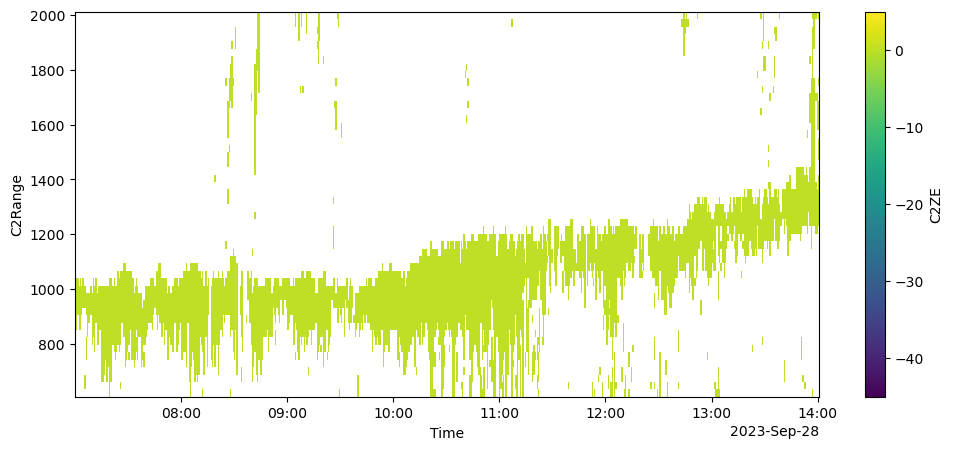

In [25]:
ds_zen["C2ZE"].plot(
    x="Time",
    y="C2Range",
    vmin=-45,
    vmax=5,
    figsize=(12,5)
)

In [24]:
print(ds_zen["C1Range"].min().values, ds_zen["C1Range"].max().values)
print(ds_zen["C2Range"].min().values, ds_zen["C2Range"].max().values)
print(ds_zen["C3Range"].min().values, ds_zen["C3Range"].max().values)

111.79539489746094 581.3360595703125
620.9869995117188 1997.958251953125
2033.46240234375 11974.833984375


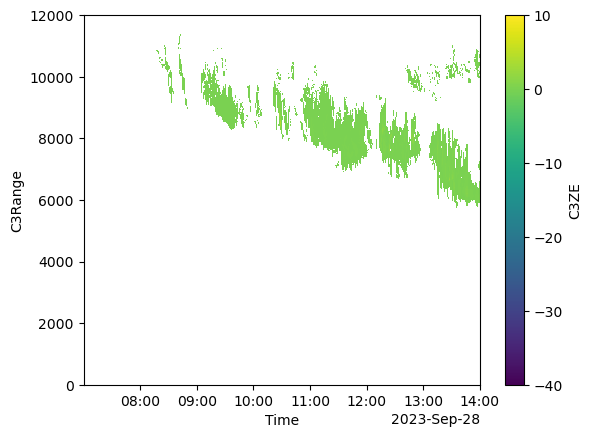

In [17]:
ds_zen["C3ZE"].plot(
    x="Time",
    y="C3Range",
    ylim=(0, 12000),
    vmin=-40,
    vmax=10,
    cmap="viridis"
)

In [8]:
ds_zen["Time"]

<xarray.DataArray 'Time' (Time: 10533)> Size: 84kB
array(['2023-09-28T07:00:04.000000', '2023-09-28T07:00:05.000000',
       '2023-09-28T07:00:06.000000', ..., '2023-09-28T14:00:30.000000',
       '2023-09-28T14:00:31.000000', '2023-09-28T14:00:32.000000'],
      shape=(10533,), dtype='datetime64[us]')
Coordinates:
  * Time     (Time) datetime64[us] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...

In [7]:
epoch = pd.Timestamp("2001-01-01 00:00:00")
ds_zen = ds_zen.assign_coords(
    Time=epoch + pd.to_timedelta(ds_zen["Time"].values, unit="s")
)

In [6]:
ds_zen["C3ZE"]

<xarray.DataArray 'C3ZE' (Time: 10533, C3Range: 265)> Size: 11MB
dask.array<concatenate, shape=(10533, 265), dtype=float32, chunksize=(79, 265), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) uint32 42kB 717577204 717577205 ... 717602431 717602432
  * C3Range  (C3Range) float32 1kB 2.033e+03 2.071e+03 ... 1.194e+04 1.197e+04
Attributes:
    Name:     Equivalent radar reflectivity factor: Chirp 3
    Units:    mm^6/m^3

In [5]:
ds_zen = xr.open_mfdataset(zen_files)

print(ds_zen)

C:\Users\geron\AppData\Local\Temp\ipykernel_21012\1329833189.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_zen = xr.open_mfdataset(zen_files)


<xarray.Dataset> Size: 236MB
Dimensions:      (Time: 10533, TAlt: 93, HAlt: 93, Chirp: 3, C1Range: 22,
                  C2Range: 52, C3Range: 265)
Coordinates:
  * Time         (Time) uint32 42kB 717577204 717577205 ... 717602431 717602432
  * C1Range      (C1Range) float32 88B 111.8 134.2 156.5 ... 536.6 559.0 581.3
  * C2Range      (C2Range) float32 208B 621.0 648.0 ... 1.971e+03 1.998e+03
  * C3Range      (C3Range) float32 1kB 2.033e+03 2.071e+03 ... 1.197e+04
Dimensions without coordinates: TAlt, HAlt, Chirp
Data variables: (12/98)
    ProgNo       (Time) int32 42kB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    ModelNo      (Time) int32 42kB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    Freq         (Time) float32 42kB 94.0 94.0 94.0 94.0 ... 94.0 94.0 94.0 94.0
    AntSep       (Time) float32 42kB 0.568 0.568 0.568 ... 0.568 0.568 0.568
    AntDia       (Time) float32 42kB 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    AntG         (Time) float32 42kB 1.072e+05 1.072e+05

In [4]:
zen_files = sorted(glob.glob(str(base_path / "*ZEN.LV1.nc")))

print("Number of ZEN files:", len(zen_files))
print(zen_files[0])

Number of ZEN files: 135
..\data\raw\cmtrace\20230928\BaseN_230928_070004_P01_ZEN.LV1.nc


In [3]:
base_path = Path("../data/raw/cmtrace/20230928")
print(base_path)
Path("../data/raw/cmtrace/20230928").exists()

..\data\raw\cmtrace\20230928


True

In [2]:
import xarray as xr
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt